In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [2]:
DATA_PATH = "C:/Users/saura/cn-project-network-security/data/amari_ue_data_classic_tabular.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

# Convert timestamp
df["_time"] = pd.to_datetime(df["_time"], errors="coerce")


In [3]:
df.shape


(424660, 80)

In [4]:
df["_time"].min(), df["_time"].max()


(Timestamp('2024-08-17 12:00:01.700000+0000', tz='UTC'),
 Timestamp('2024-08-22 06:59:55.404000+0000', tz='UTC'))

## Key Traffic Features for Analysis

Based on the reference paper and dataset documentation,
we focus on the following UE-level features:

- ul_bitrate : Uplink bitrate (bps)
- dl_bitrate : Downlink bitrate (bps)
- cell_X_ul_retx : Uplink retransmissions
- cell_X_dl_retx : Downlink retransmissions

These features are indicative of abnormal behavior
during DDoS attacks.


In [5]:
ue_counts = df["imeisv"].value_counts()

ue_counts


imeisv
8609960480859058    76275
8609960468879057    76266
8642840401594200    76205
3557821101183501    75724
8642840401624200    75304
8677660403123800    44885
8609960480666910        1
Name: count, dtype: int64

Each IMEISV corresponds to a unique UE.
Some UEs generate significantly more samples,
which may indicate continuous traffic generation
or malicious behavior.


In [7]:
ue_avg_traffic = (
    df.groupby("imeisv")[["ul_bitrate", "dl_bitrate"]]
    .mean()
    .sort_values(by="ul_bitrate", ascending=False)
)

ue_avg_traffic


,ul_bitrate,dl_bitrate
imeisv,,
8609960468879057,1.202490e+07,2.560327e+06
8609960480859058,6.043275e+06,2.535858e+06
8642840401624200,2.044111e+05,4.932373e+03
8677660403123800,3.291392e+03,6.308657e+03
8642840401594200,3.167807e+03,3.652884e+03
3557821101183501,2.770605e+03,5.271866e+03
8609960480666910,0.000000e+00,0.000000e+00


UEs show clear differences in average uplink and downlink
traffic behavior. Some UEs exhibit disproportionately
high uplink bitrate, which is a known characteristic
of flooding-based DDoS attacks.


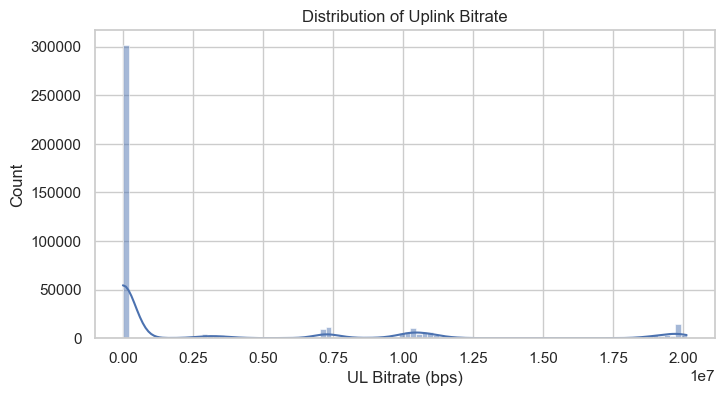

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df["ul_bitrate"], bins=100, kde=True)
plt.title("Distribution of Uplink Bitrate")
plt.xlabel("UL Bitrate (bps)")
plt.ylabel("Count")
plt.show()


The uplink bitrate distribution is highly skewed,
indicating the presence of extreme values.
Such heavy-tailed behavior motivates the use
of anomaly detection techniques.


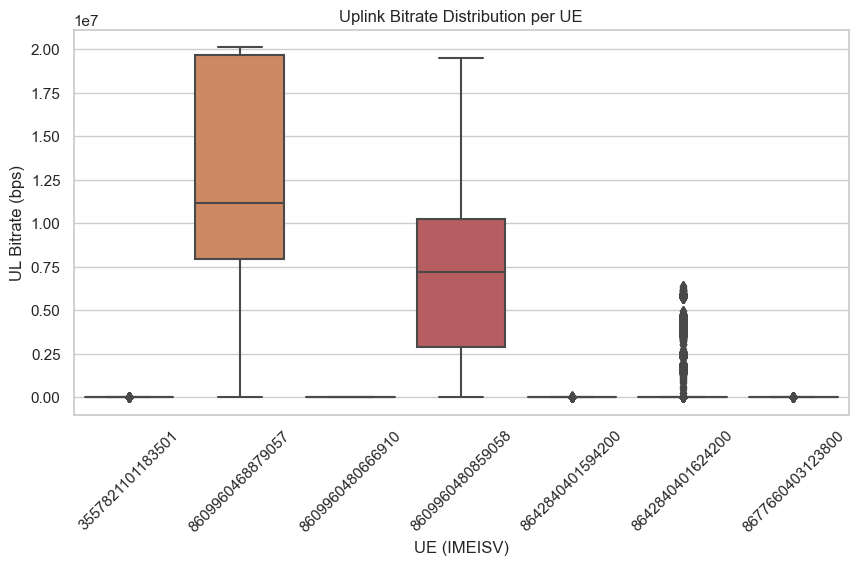

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="imeisv",
    y="ul_bitrate",
    data=df
)
plt.xticks(rotation=45)
plt.title("Uplink Bitrate Distribution per UE")
plt.xlabel("UE (IMEISV)")
plt.ylabel("UL Bitrate (bps)")
plt.show()


Certain UEs show limited variability and consistently
high uplink bitrate, which is indicative of automated,
repetitive traffic generation typically observed in
DDoS attacks.

In contrast, benign UEs exhibit higher variability
in uplink bitrate, reflecting normal user behavior
such as video streaming.


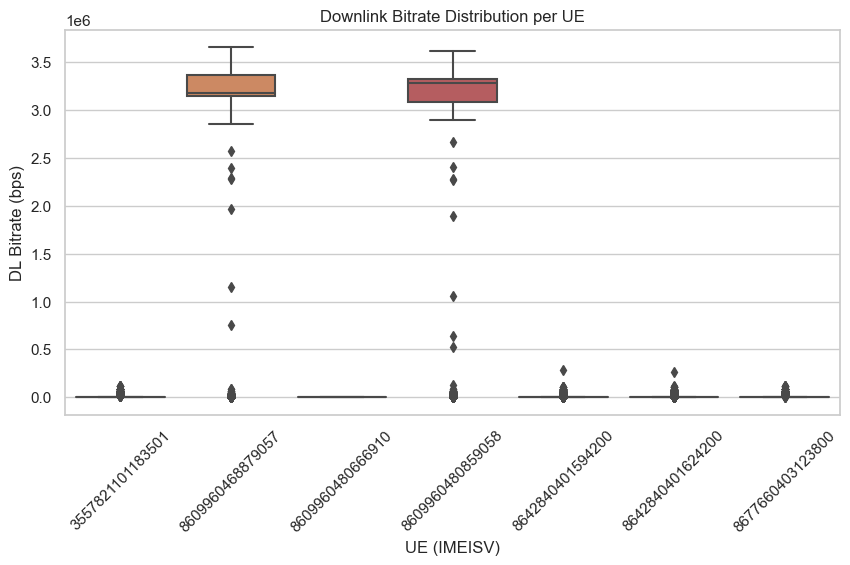

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="imeisv",
    y="dl_bitrate",
    data=df
)
plt.xticks(rotation=45)
plt.title("Downlink Bitrate Distribution per UE")
plt.xlabel("UE (IMEISV)")
plt.ylabel("DL Bitrate (bps)")
plt.show()


Downlink bitrate patterns further distinguish UE behavior.
Benign users consuming streaming services tend to exhibit
higher and more variable downlink traffic compared to
malicious UEs.


In [12]:
[col for col in df.columns if "ul_retx" in col.lower()]


['cell_1_ul_retx', 'cell_3_ul_retx']

#### Create a Consolidated UL Retransmission Feature

In [13]:
ul_retx_cols = ['cell_1_ul_retx', 'cell_3_ul_retx']

df["ul_retx_max"] = df[ul_retx_cols].max(axis=1)


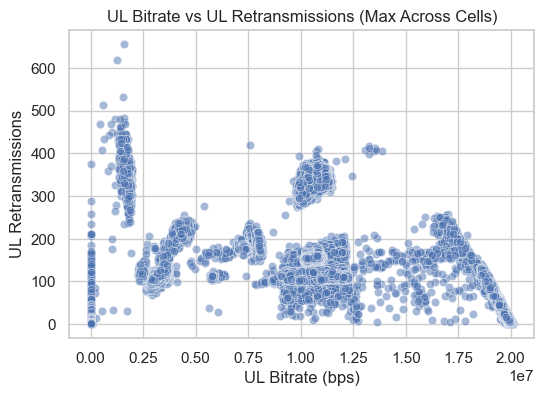

In [14]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x="ul_bitrate",
    y="ul_retx_max",
    data=df,
    alpha=0.5
)
plt.title("UL Bitrate vs UL Retransmissions (Max Across Cells)")
plt.xlabel("UL Bitrate (bps)")
plt.ylabel("UL Retransmissions")
plt.show()


The dataset provides uplink retransmission counters per cell.
Since a UE is associated with a single serving cell at any
given time, retransmission metrics are consolidated by
selecting the maximum value across all available cells.

The resulting plot shows that high uplink bitrate is often
accompanied by increased retransmissions, a characteristic
of flooding-based DDoS traffic.


In [16]:
# Identify DL retransmission columns
dl_retx_cols = [col for col in df.columns if col.startswith("cell_") and "dl_retx" in col]

dl_retx_cols


['cell_1_dl_retx', 'cell_3_dl_retx']

In [17]:
df["dl_retx_max"] = df[dl_retx_cols].max(axis=1)


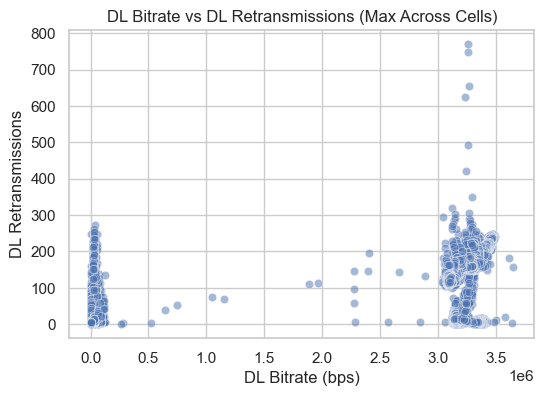

In [18]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x="dl_bitrate",
    y="dl_retx_max",
    data=df,
    alpha=0.5
)
plt.title("DL Bitrate vs DL Retransmissions (Max Across Cells)")
plt.xlabel("DL Bitrate (bps)")
plt.ylabel("DL Retransmissions")
plt.show()


Downlink retransmissions increase with higher downlink bitrate
for certain UEs. However, compared to uplink traffic, the
relationship is less pronounced, as DDoS attacks primarily
target uplink flooding toward network services.


In [20]:
# Create a clean copy for time-series plotting
df_ts = df.dropna(subset=["_time"]).copy()

# Convert timezone-aware timestamps to timezone-naive
df_ts["_time"] = df_ts["_time"].dt.tz_convert(None)


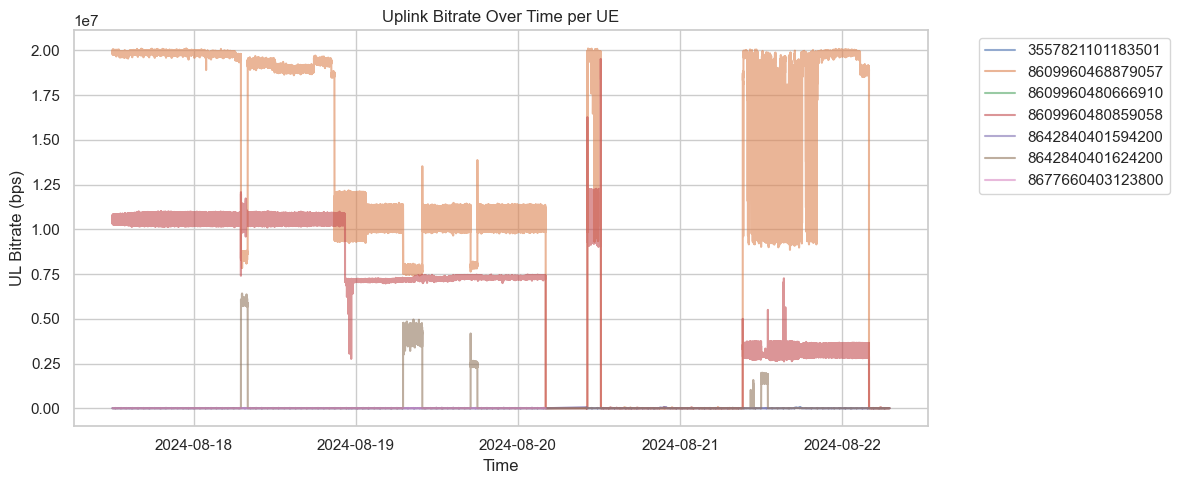

In [21]:
plt.figure(figsize=(12, 5))

for ue in df_ts["imeisv"].unique():
    ue_data = df_ts[df_ts["imeisv"] == ue]
    plt.plot(
        ue_data["_time"],
        ue_data["ul_bitrate"],
        label=str(ue),
        alpha=0.6
    )

plt.title("Uplink Bitrate Over Time per UE")
plt.xlabel("Time")
plt.ylabel("UL Bitrate (bps)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


For visualization purposes, timestamps were converted to
timezone-naive format after removing missing values.
This transformation is applied only for plotting and does
not affect the original temporal semantics of the dataset.

The time-series plot highlights sustained high uplink
transmission patterns for certain UEs, which aligns with
the flooding behavior observed during DDoS attacks.


In [22]:
eda_features = [
    "ul_bitrate",
    "dl_bitrate",
    "ul_retx_max",
    "dl_retx_max"
]

corr = df[eda_features].corr()
corr


,ul_bitrate,dl_bitrate,ul_retx_max,dl_retx_max
ul_bitrate,1.000000,0.885121,0.524819,0.546450
dl_bitrate,0.885121,1.000000,0.747169,0.728081
ul_retx_max,0.524819,0.747169,1.000000,0.535603
dl_retx_max,0.546450,0.728081,0.535603,1.000000


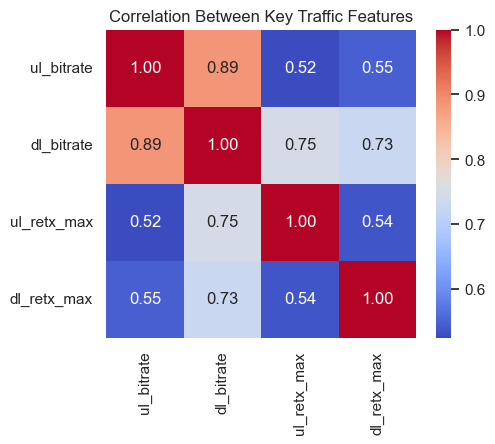

In [23]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Key Traffic Features")
plt.show()


Uplink bitrate shows a stronger correlation with uplink
retransmissions compared to downlink features. This supports
the hypothesis that uplink-based metrics are more informative
for detecting flooding-style DDoS attacks.


## Summary of Exploratory Data Analysis

This notebook performed an exploratory analysis of UE-level
network traffic without using explicit attack labels.
The objective was to understand traffic behavior, variability,
and relationships among key features prior to preprocessing
and supervised learning.

Key observations include:

1. **Uplink Bitrate Distribution**
   - The global uplink bitrate distribution is highly skewed
     with a heavy tail, indicating the presence of extreme
     traffic values.
   - Such behavior is characteristic of network traffic under
     flooding conditions and motivates the use of anomaly
     detection techniques rather than simple thresholding.

2. **UE-wise Uplink Bitrate Behavior**
   - Boxplot analysis reveals that certain UEs exhibit
     consistently high uplink bitrate with limited variability,
     which is indicative of automated, repetitive traffic
     generation.
   - In contrast, other UEs show higher variability and lower
     median uplink rates, consistent with benign user behavior
     such as video streaming.

3. **Downlink Bitrate Patterns**
   - Downlink bitrate distributions indicate that benign UEs
     consuming streaming services exhibit higher and more
     variable downlink traffic.
   - Malicious UEs tend to show comparatively lower and more
     constrained downlink activity, reinforcing the asymmetry
     between uplink- and downlink-driven attacks.

4. **Retransmissions and Traffic Intensity**
   - Uplink retransmissions increase with higher uplink bitrate,
     suggesting network stress caused by aggressive traffic
     generation.
   - Downlink retransmissions show a weaker relationship with
     bitrate, consistent with DDoS attacks primarily targeting
     uplink flooding toward network services.

5. **Temporal Traffic Evolution**
   - Time-series analysis of uplink bitrate per UE reveals
     sustained high-rate transmission periods for specific UEs,
     contrasting with bursty and intermittent patterns observed
     for benign users.
   - These temporal patterns provide strong intuition for
     time-window–based labeling of attack traffic.

6. **Feature Correlation**
   - Uplink and downlink bitrates are strongly correlated,
     reflecting overall traffic load.
   - Uplink retransmissions show moderate correlation with
     uplink bitrate, supporting their usefulness as anomaly
     indicators.

Overall, the exploratory analysis demonstrates clear behavioral
differences between benign and potentially malicious UEs.
These findings align with observations reported in the
reference paper and justify framing the problem as a binary
classification task using ML-based anomaly detection.

In the next notebook, explicit attack labels will be derived
using known attack time windows, followed by data preprocessing.
